# 02 - AEMO DER Register Data Exploration (Queensland Focus)

**Project:** DER Integration in Queensland

**Author:** Johan Lopez

**Date:** February 15, 2026

**Purpose:** Load and explore AEMO DER Register data with specific focus on Queensland. Understand data structure, identify trends, and lay groundwork for integration analysis.

**Data Source:** AEMO DER Register (https://www.aemo.com.au/energy-systems/electricity/der-register/data-der/data-downloads)

**Reporting Date:** December, 2025

---

## 1. Setup & Imports

In [13]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilities
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add project src directory to path for custom modules
project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(project_root, 'src'))

# Import custom data loader
from data_loader import load_aemo_data

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ Libraries imported successfully!
Analysis Date: 2026-05-17 16:16


## 2. Define File Paths

Set up paths to data folders relative to project root.

In [14]:
# Project structure
project_root = os.path.dirname(os.getcwd())
data_raw = os.path.join(project_root, 'data', 'raw')
data_processed = os.path.join(project_root, 'data', 'processed')
outputs_figures = os.path.join(project_root, 'outputs', 'figures')

print(f"Project root: {project_root}")
print(f"Data raw folder: {data_raw}")

Project root: C:\Users\jlope\JotaLabs\DER-Integration-QLD
Data raw folder: C:\Users\jlope\JotaLabs\DER-Integration-QLD\data\raw


In [15]:
# Load AEMO DER Register data using flexible loader
# This handles:
#   - CSV or Excel (.xlsx) formats
#   - Various file naming patterns (aemo_der_register*.csv, DER_Register*.xlsx, etc.)
#   - Multi-sheet Excel files

df_raw = load_aemo_data(data_raw_path=data_raw)

print(f"\n✓ Data loaded successfully!")
print(f"  Total rows: {len(df_raw):,}")
print(f"  Total columns: {len(df_raw.columns)}")

Loading AEMO data: der_register_march.xlsx
  ✓ Standardized 15 column names
    'Bus_Resid' → 'nmi_bus_res'
    'Sum of Num_DER_Sites' → 'DER_Sites'
    'Sum of Num_DER_Connections' → 'DER_Connections'
    'Sum of Installed_DER_capacity_kVA' → 'Installed_DER_capacity_kVA'
    'Sum of Solar_Connections' → 'Solar_Connections'
    'Sum of Solar_Devices' → 'Solar_Devices'
    'Sum of Solar_capacity_kVA' → 'Solar_capacity_kVA'
    'Sum of Battery_Connections' → 'Battery_Connections'
    'Sum of Battery_Devices' → 'Battery_Devices'
    'Sum of Battery_capacity_kVA' → 'Battery_capacity_kVA'
    'Sum of Battery_Storage_kVAh' → 'Battery_Storage_kVAh'
    'Sum of Num_Other_Connections' → 'Num_Other_Connections'
    'Sum of Installed_OtherDER_capacity_kVA' → 'Installed_OtherDER_capacity_kVA'
✓ Loaded 4,093 rows × 15 columns

✓ Data loaded successfully!
  Total rows: 4,093
  Total columns: 15


## 3. Initial Data Exploration

Let's understand what we're working with.

In [16]:
# Display first few rows
print("First 5 rows of data:")
print("=" * 80)
df_raw.head()

First 5 rows of data:


,state,postcode,nmi_bus_res,DER_Sites,DER_Connections,Installed_DER_capacity_kVA,Solar_Connections,Solar_Devices,Solar_capacity_kVA,Battery_Connections,Battery_Devices,Battery_capacity_kVA,Battery_Storage_kVAh,Num_Other_Connections,Installed_OtherDER_capacity_kVA
0,ACT,<10 sites,NaN,28,41,32606,33,953,516,4,4,27,70,4,32062.00
1,SA,<10 sites,NaN,853,1783,122884,1523,37151,44323,250,330,5661,6315,10,72900.00
2,TAS,<10 sites,NaN,197,315,4916,230,9526,3278,83,94,516,18781,2,1121.00
3,QLD,<10 sites,NaN,706,1168,10489,1102,19183,9419,66,86,1070,1951,0,0.00
4,VIC,<10 sites,NaN,1355,3078,228885,2777,41869,20507,281,270,8332,12615,20,200045.00


In [17]:
# Column names and types
print("Column Information:")
print("=" * 80)
print(df_raw.dtypes)
print("\n" + "=" * 80)

Column Information:
state                                  str
postcode                               str
nmi_bus_res                            str
DER_Sites                            int64
DER_Connections                      int64
Installed_DER_capacity_kVA           int64
Solar_Connections                    int64
Solar_Devices                        int64
Solar_capacity_kVA                   int64
Battery_Connections                  int64
Battery_Devices                      int64
Battery_capacity_kVA                 int64
Battery_Storage_kVAh                 int64
Num_Other_Connections                int64
Installed_OtherDER_capacity_kVA    float64
dtype: object



In [18]:
# Basic statistics
print("Numeric Column Statistics:")
print("=" * 80)
df_raw.describe()

Numeric Column Statistics:


,DER_Sites,DER_Connections,Installed_DER_capacity_kVA,Solar_Connections,Solar_Devices,Solar_capacity_kVA,Battery_Connections,Battery_Devices,Battery_capacity_kVA,Battery_Storage_kVAh,Num_Other_Connections,Installed_OtherDER_capacity_kVA
count,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00,4093.00
mean,777.87,1046.06,5919.17,969.77,7934.47,4939.58,76.20,89.28,753.65,1312.57,0.09,225.96
std,1725.37,2136.93,12660.77,1984.40,17996.63,10293.71,166.83,204.78,1969.19,3077.96,0.56,3796.88
min,10.00,10.00,0.00,5.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37.00,50.00,370.00,48.00,494.00,327.00,1.00,1.00,10.00,20.00,0.00,0.00
50%,122.00,185.00,1458.00,178.00,1796.00,1228.00,6.00,9.00,71.00,137.00,0.00,0.00
75%,679.00,1000.00,5859.00,933.00,7623.00,5021.00,61.00,69.00,595.00,1134.00,0.00,0.00
max,24461.00,25917.00,228885.00,24684.00,280221.00,144261.00,1426.00,2067.00,52047.00,49097.00,20.00,200045.00


In [19]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 80)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))
print("\n" + "=" * 80)

Missing Values Analysis:
             Missing Count  Missing %
nmi_bus_res              6       0.15



In [20]:
# Unique states in dataset
print("States/Territories in Dataset:")
print("=" * 80)
if 'state' in df_raw.columns:
    print(df_raw['state'].value_counts())
else:
    print("State column not found - showing all columns:")
    print(df_raw.columns.tolist())

States/Territories in Dataset:
state
VIC    1256
NSW    1122
QLD     858
SA      633
TAS     172
ACT      52
Name: count, dtype: int64


## 5. Filter for Queensland Data

Extract only Queensland postcodes for focused analysis.

In [21]:
# Filter for Queensland
# Note: Adjust column names based on actual data structure
# Queensland postcodes typically start with 4 (4000-4999)

# Method 1: If there's a State column
state_col = 'state'

df_qld = df_raw[df_raw[state_col].str.contains('QLD', case=False, na=False)].copy()
print(f"✓ Filtered by State column: {state_col}")

print(f"\nQueensland Data:")
print(f"  Total QLD rows: {len(df_qld):,}")
print(f"  Percentage of total: {(len(df_qld)/len(df_raw)*100):.1f}%")

✓ Filtered by State column: state

Queensland Data:
  Total QLD rows: 858
  Percentage of total: 21.0%


In [22]:
# Quick look at Queensland data
print("Queensland DER Data Sample:")
print("=" * 80)
df_qld.head(10)

Queensland DER Data Sample:


,state,postcode,nmi_bus_res,DER_Sites,DER_Connections,Installed_DER_capacity_kVA,Solar_Connections,Solar_Devices,Solar_capacity_kVA,Battery_Connections,Battery_Devices,Battery_capacity_kVA,Battery_Storage_kVAh,Num_Other_Connections,Installed_OtherDER_capacity_kVA
3,QLD,<10 sites,NaN,706,1168,10489,1102,19183,9419,66,86,1070,1951,0,0.00
1178,QLD,2406,RESIDENTIAL,13,13,6,13,13,6,0,0,0,0,0,0.00
1179,QLD,4000,BUSINESS,92,168,11895,166,8418,7405,1,2,40,60,1,4450.00
1180,QLD,4000,RESIDENTIAL,296,393,1948,354,2513,1566,39,47,382,771,0,0.00
1181,QLD,4005,BUSINESS,42,46,902,43,1178,867,3,4,35,87,0,0.00
1182,QLD,4005,RESIDENTIAL,890,1721,6879,1633,9965,5872,88,114,1006,1620,0,0.00
1183,QLD,4006,BUSINESS,227,539,8002,531,10675,7544,7,7,107,186,1,350.00
1184,QLD,4006,RESIDENTIAL,293,410,2357,367,3225,1986,43,59,371,651,0,0.00
1185,QLD,4007,BUSINESS,66,88,2775,86,4071,2460,2,11,315,77,0,0.00
1186,QLD,4007,RESIDENTIAL,1219,1864,10771,1700,15570,8749,164,225,2022,3200,0,0.00


## 6. Data Understanding - Key Metrics

Calculate high-level statistics for Queensland DER deployment.

In [23]:
#Columns
print("Queensland DER Summary Statistics:")
print("=" * 80)

# Identify relevant columns
print("\nAvailable columns in Queensland data:")
for i, col in enumerate(df_qld.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 80)
print("NOTE: In the next cell, we'll calculate specific metrics once we identify the column names.")

Queensland DER Summary Statistics:

Available columns in Queensland data:
1. state
2. postcode
3. nmi_bus_res
4. DER_Sites
5. DER_Connections
6. Installed_DER_capacity_kVA
7. Solar_Connections
8. Solar_Devices
9. Solar_capacity_kVA
10. Battery_Connections
11. Battery_Devices
12. Battery_capacity_kVA
13. Battery_Storage_kVAh
14. Num_Other_Connections
15. Installed_OtherDER_capacity_kVA

NOTE: In the next cell, we'll calculate specific metrics once we identify the column names.


In [24]:
# Calculate summary metrics


total_solar_installs = df_qld['Solar_Connections'].sum()
total_solar_capacity = df_qld['Solar_capacity_kVA'].sum()
total_solar_devices = df_qld['Solar_Devices'].sum()
total_battery_installs = df_qld['Battery_Connections'].sum()
total_battery_capacity = df_qld['Battery_capacity_kVA'].sum()
total_battery_devices = df_qld['Battery_Devices'].sum()
total_battery_storage = df_qld['Battery_Storage_kVAh'].sum()


print(f"Queensland DER Deployment (as of December 2025):")
print(f"  Solar PV Installations: {total_solar_installs:,}")
print(f"  Total Solar Capacity: {total_solar_capacity:,.0f} kW ({total_solar_capacity/1000:.1f} MW)")
print(f"  Battery Installations: {total_battery_installs:,} and devices:"f"{total_battery_devices:,}")
print(f"  Total Battery Capacity: {total_battery_capacity:,.0f} kWh ({total_battery_capacity/1000:.1f} MWh)")


Queensland DER Deployment (as of December 2025):
  Solar PV Installations: 1,163,013
  Total Solar Capacity: 7,075,597 kW (7075.6 MW)
  Battery Installations: 85,684 and devices:119,167
  Total Battery Capacity: 994,564 kWh (994.6 MWh)


## 7. Geographic Distribution Analysis

Understand where DER is concentrated in Queensland.

In [25]:
# Top postcodes by DER deployment

print("Top 20 Queensland Postcodes by DER Deployment:")
print("=" * 80)


top_postcodes = df_qld.groupby('postcode').agg({
    'Solar_Connections': 'sum',
    'Solar_capacity_kVA': 'sum',
    'Battery_Connections': 'sum'
}).sort_values('Solar_capacity_kVA', ascending=False).head(20)
print(top_postcodes)

Top 20 Queensland Postcodes by DER Deployment:
          Solar_Connections  Solar_capacity_kVA  Battery_Connections
postcode                                                            
4740                  17702              173603                 1269
4670                  22540              139990                 1254
4350                  25334              124668                 1044
4655                  22166              119384                 1039
4207                  15546              116084                 1268
4551                  17818              110374                 1241
4870                  17069              107137                  966
4300                  15411              101442                 1318
4209                  13663               97032                 1268
4306                  14216               87682                 1316
4680                  12103               86127                  648
4510                  13698               84649         

## 8. Visualization - DER Distribution Map

Create visual representation of Queensland DER deployment.

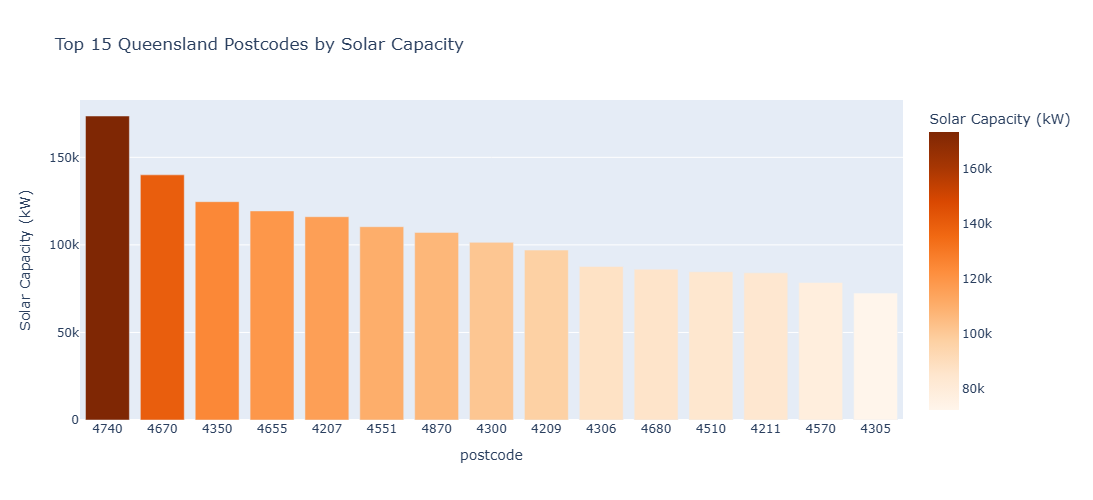

In [26]:
# Bar chart of top postcodes



fig = px.bar(top_postcodes.head(15), 
             x=top_postcodes.head(15).index,
             y='Solar_capacity_kVA',
             title='Top 15 Queensland Postcodes by Solar Capacity',
             labels={'x': 'postcode', 'Solar_capacity_kVA': 'Solar Capacity (kW)'},
             color='Solar_capacity_kVA',
             color_continuous_scale='Oranges')
fig.update_layout(height=500, showlegend=False)
fig.show()

## 9. Business vs Residential Analysis

Understand the split between business and residential DER installations.

In [27]:
# Check if business/residential classification exists
# Note: Column name is now standardized by data_loader to 'nmi_bus_res'

classification_col = "nmi_bus_res"

print("\nDistribution:")
print(df_qld[classification_col].value_counts())



Distribution:
nmi_bus_res
RESIDENTIAL    414
BUSINESS       373
UNKNOWN         70
Name: count, dtype: int64


## 10. Data Quality Assessment

Identify any issues or gaps in the Queensland data.

In [28]:
print("Data Quality Check:")
print("=" * 80)

# Check for duplicates
duplicates = df_qld.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for missing critical fields
critical_missing = df_qld.isnull().sum()
if critical_missing.sum() > 0:
    print("\nMissing values in Queensland data:")
    print(critical_missing[critical_missing > 0])
else:
    print("\n✓ No missing values in Queensland data")

# Check data types
print("\nData types:")
print(df_qld.dtypes)

Data Quality Check:
Duplicate rows: 0

Missing values in Queensland data:
nmi_bus_res    1
dtype: int64

Data types:
state                                  str
postcode                               str
nmi_bus_res                            str
DER_Sites                            int64
DER_Connections                      int64
Installed_DER_capacity_kVA           int64
Solar_Connections                    int64
Solar_Devices                        int64
Solar_capacity_kVA                   int64
Battery_Connections                  int64
Battery_Devices                      int64
Battery_capacity_kVA                 int64
Battery_Storage_kVAh                 int64
Num_Other_Connections                int64
Installed_OtherDER_capacity_kVA    float64
dtype: object


## 11. Save Processed Queensland Data

Save the cleaned Queensland subset for future analysis.

In [29]:
# Save Queensland data
qld_output_file = os.path.join(data_processed, 'qld_der_data.csv')
df_qld.to_csv(qld_output_file, index=False)
print(f"✓ Queensland data saved to: {qld_output_file}")
print(f"  Rows saved: {len(df_qld):,}")
print(f"  File size: {os.path.getsize(qld_output_file) / 1024:.1f} KB")

✓ Queensland data saved to: C:\Users\jlope\JotaLabs\DER-Integration-QLD\data\processed\qld_der_data.csv
  Rows saved: 858
  File size: 55.4 KB


## 12. Key Findings & Next Steps

In [30]:
print("="*80)
print("KEY FINDINGS - Initial Exploration")
print("="*80)
print("\n1. Data Structure:")
print(f"   - Total Queensland postcodes: {df_qld['postcode' if 'postcode' in df_qld.columns else df_qld.columns[0]].nunique() if len(df_qld) > 0 else 'N/A'}")
print(f"   - Data reporting date: December, 2025")
print(f"   - Aggregation level: Postcode")

print("\n2. Data Quality:")
print(" No duplicates, neglectable missing values and 74 unknown classifcations subject to further analysis and discovery")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("\n1. Identify exact column names and create summary statistics")
print("2. Create visualizations of DER growth trends and more advanced visual, including maps")
print("3. Analyze geographic clustering patterns")
print("4. Investigate data integration challenges across postcodes")
print("5. Begin protocol/standards analysis for data integration")
print("\n" + "="*80)

KEY FINDINGS - Initial Exploration

1. Data Structure:
   - Total Queensland postcodes: 417
   - Data reporting date: December, 2025
   - Aggregation level: Postcode

2. Data Quality:
 No duplicates, neglectable missing values and 74 unknown classifcations subject to further analysis and discovery

NEXT STEPS

1. Identify exact column names and create summary statistics
2. Create visualizations of DER growth trends and more advanced visual, including maps
3. Analyze geographic clustering patterns
4. Investigate data integration challenges across postcodes
5. Begin protocol/standards analysis for data integration



---

## Notes & Observations

**Document your findings here:**


### Interesting Patterns:
- More adoption by business types than residential
- Mackay and Bundi are the top places adopting DERs

### Questions for Further Investigation:
- What's the correlation between Mackay and Bundi to be on top


### Data Integration Insights:
- What standardization challenges are visible in this aggregated data?
- Installed DER capacity sometimes differ greatly from actual usage, infrastructure exists but lacks adoption?

---


**Last Updated:** February 15, 2026

**Status:** 🚧 Finished - Initial understanding of dataset, columns and QLD filtered dataset extracted